running time of insecure controller: 0.0502469539642334
running time of secure controller: 1.005328893661499
running time of secure /running time of insecure : 20.00775797030619

INSECURE CONTROLLED SYSTEM STEP RESPONSE CHARACTERISTICS

Insecure controlled system constant time :0.7376429680157821
Insecure controlled system risingtime :1.6228145296347207
Insecure controlled system settlingtime :25.574364029462753
Insecure controlled system "peak amplitude :1.38" "overshoot :38.4" "At time :5.32"

SECURE CONTROLLED SYSTEM STEP RESPONSE CHARACTERISTICS

Secure controlled system constant time :0.7464442114551834
Secure controlled system risingtime :1.6421772652014035
Secure controlled system settlingtime :25.95492793360755
Secure controlled system "peak amplitude :1.4" "overshoot :39.6" "At time :5.32"
+----------------+---------------------------------------------+---------------------------------------------------+----------------------+--------------------+
|     Signal     |        Int

Text(0.5,0,'Time (sec)')

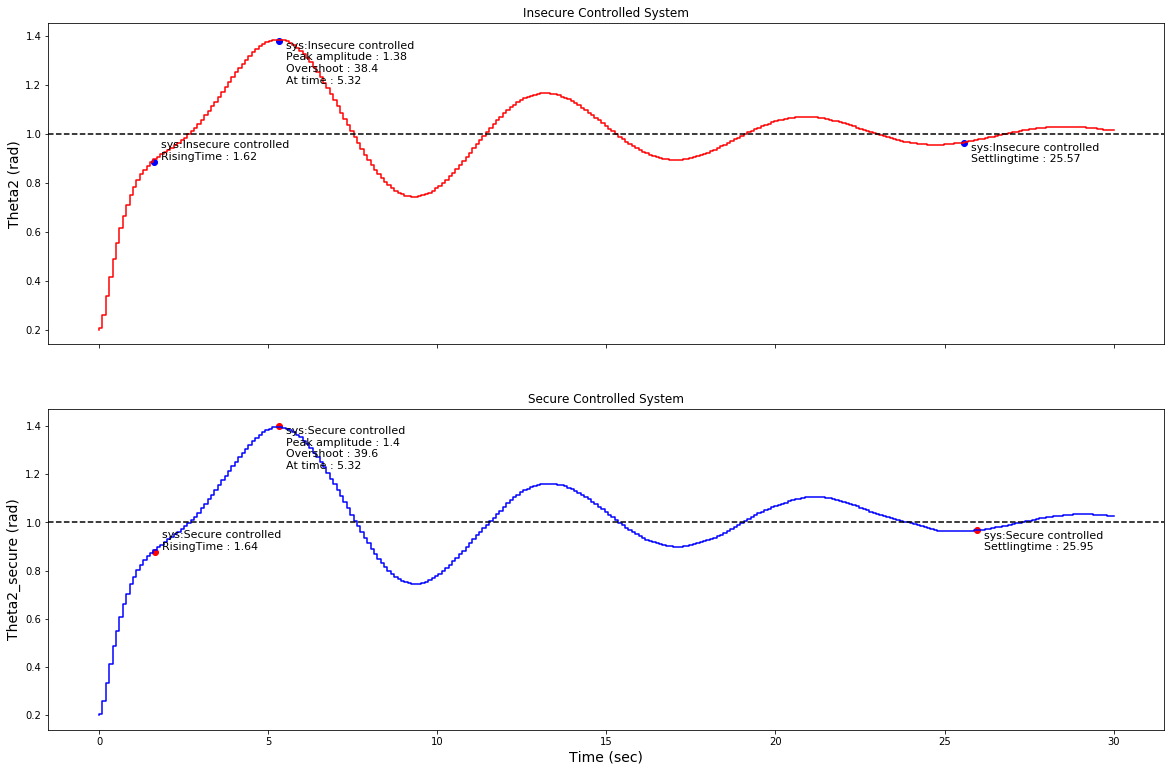

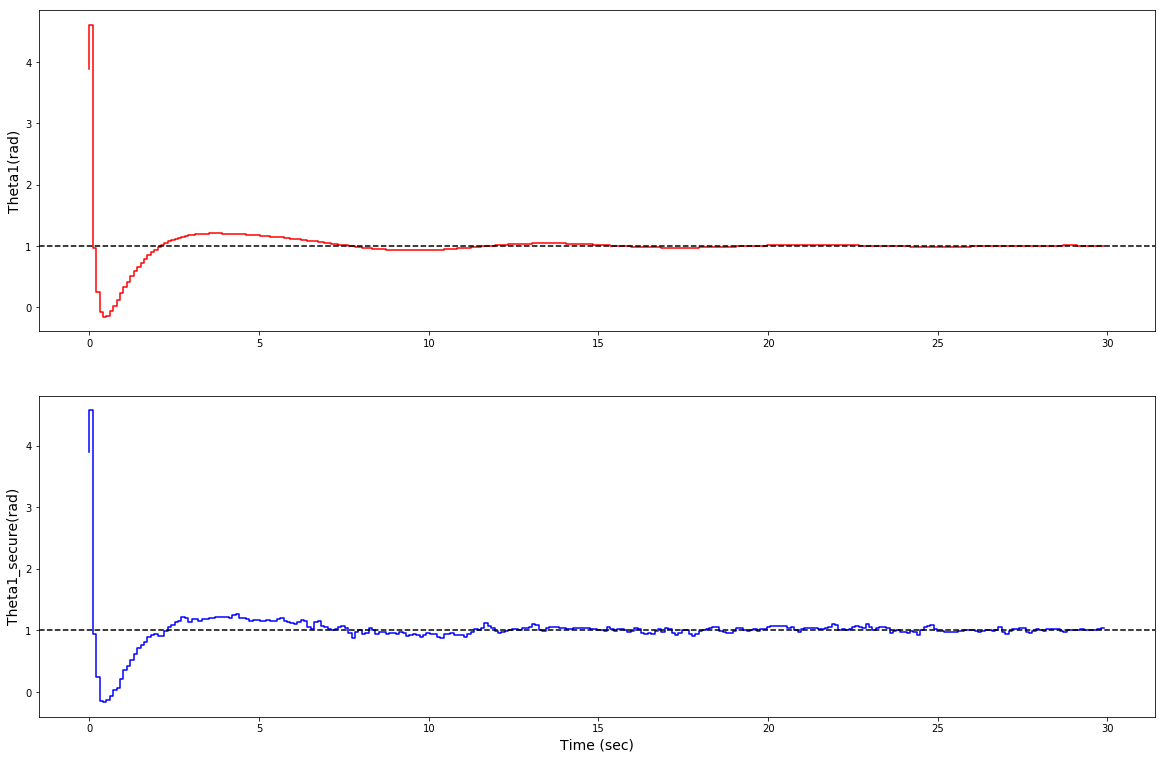

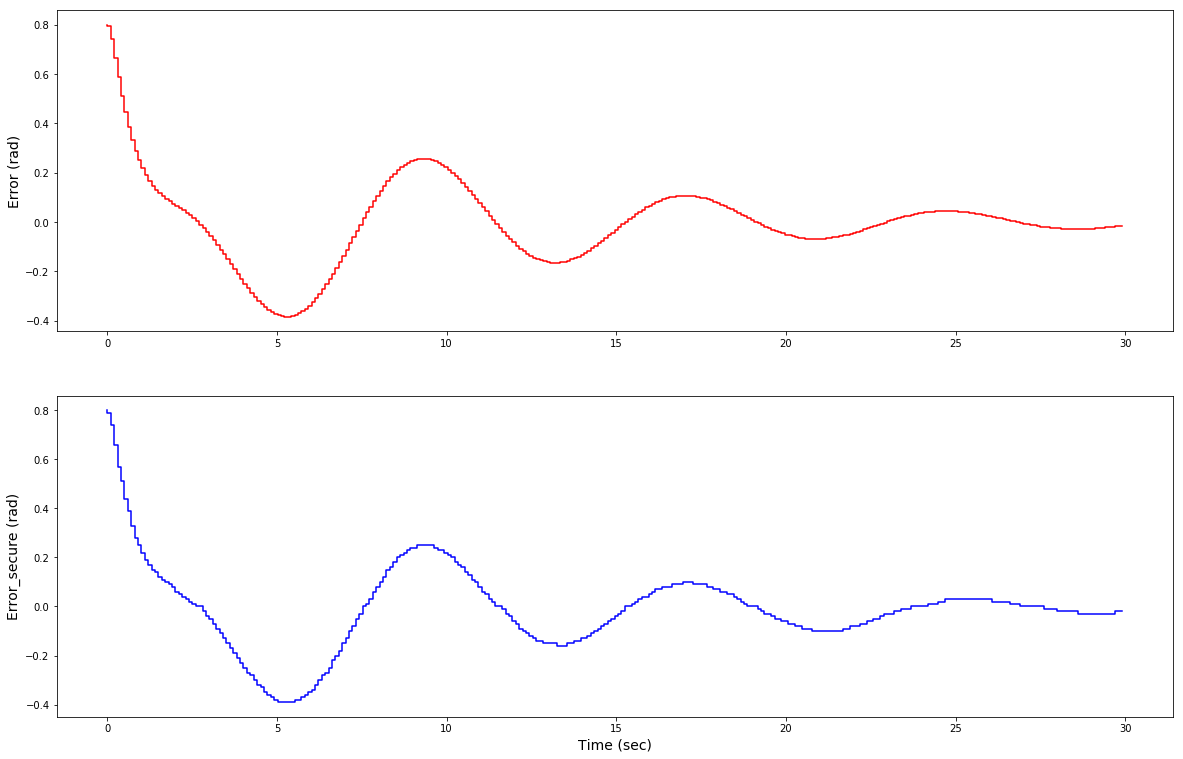

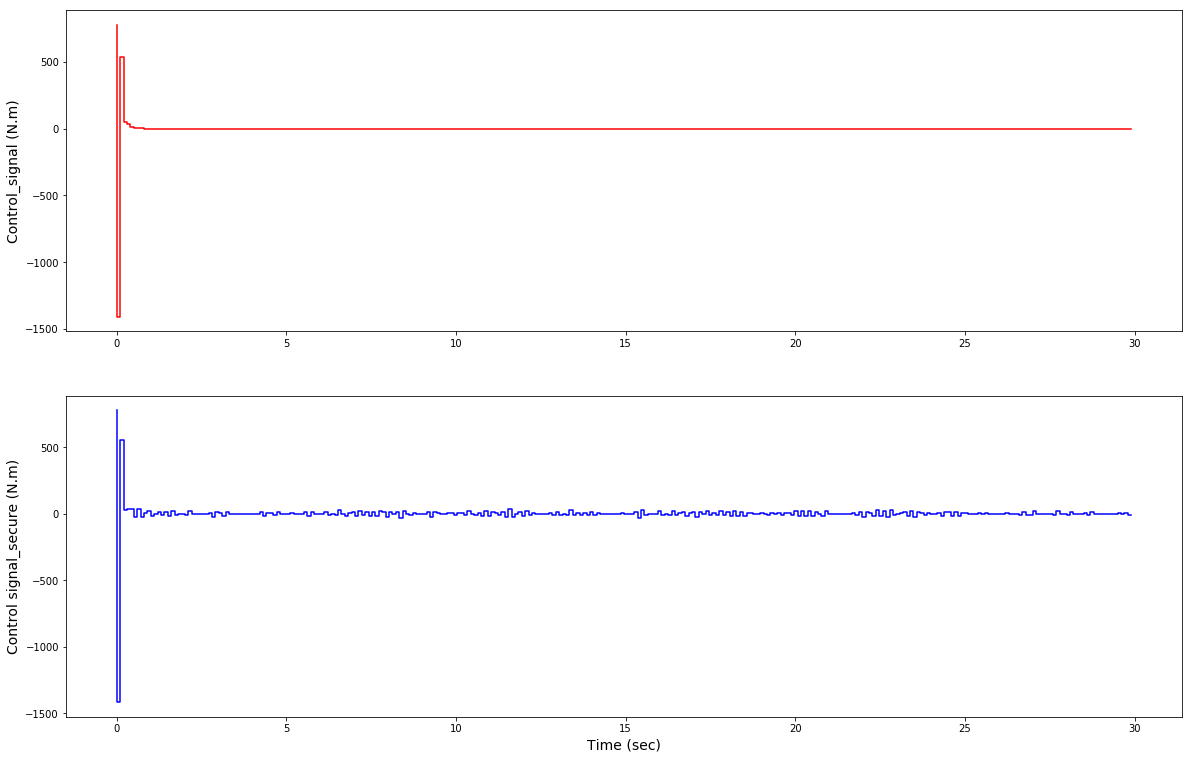

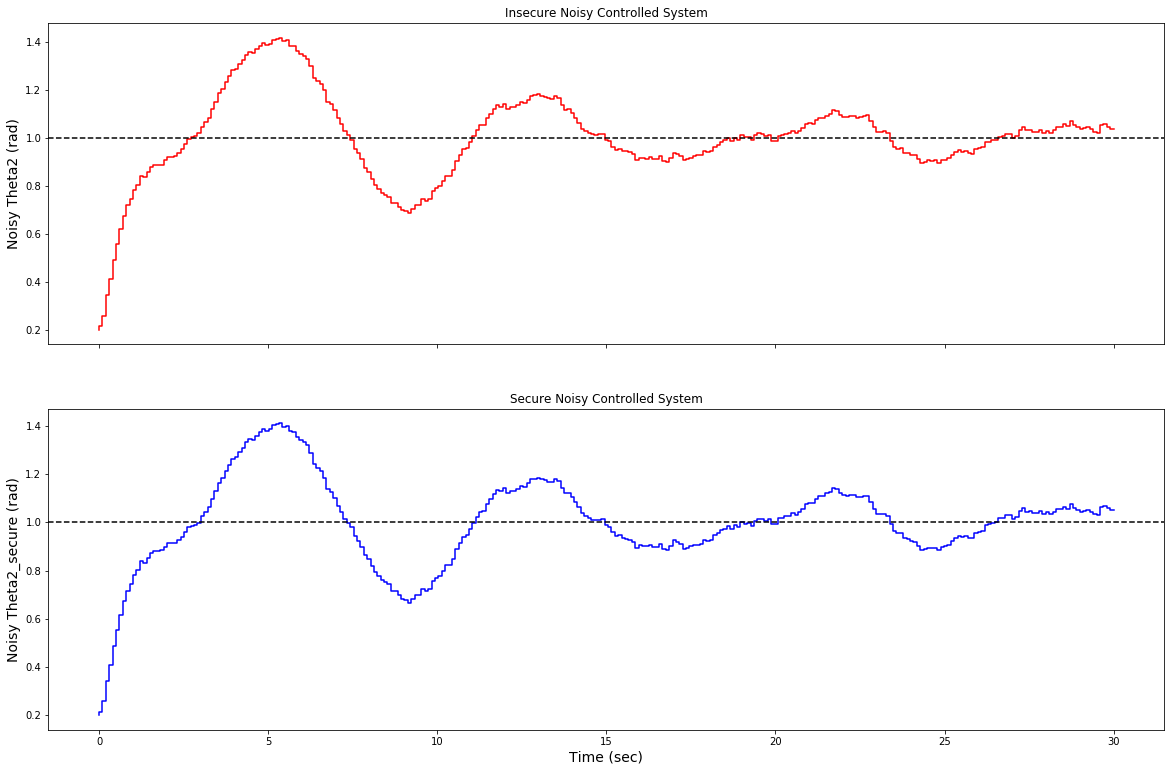

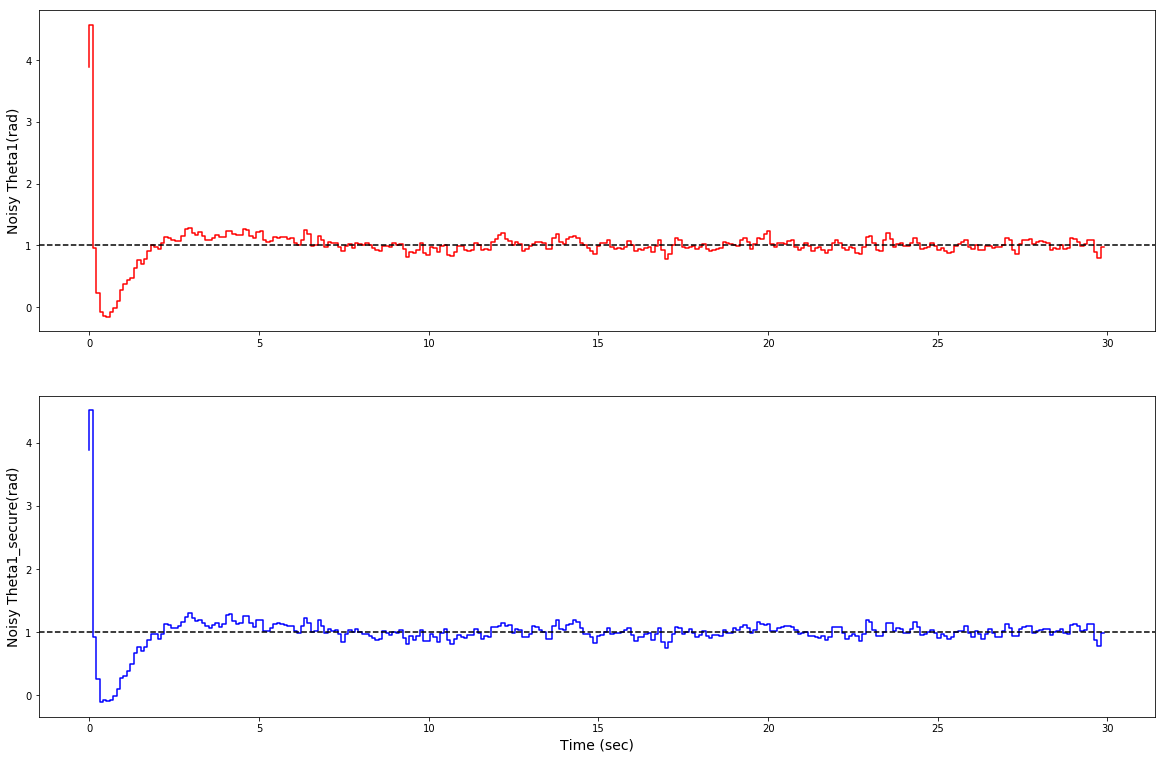

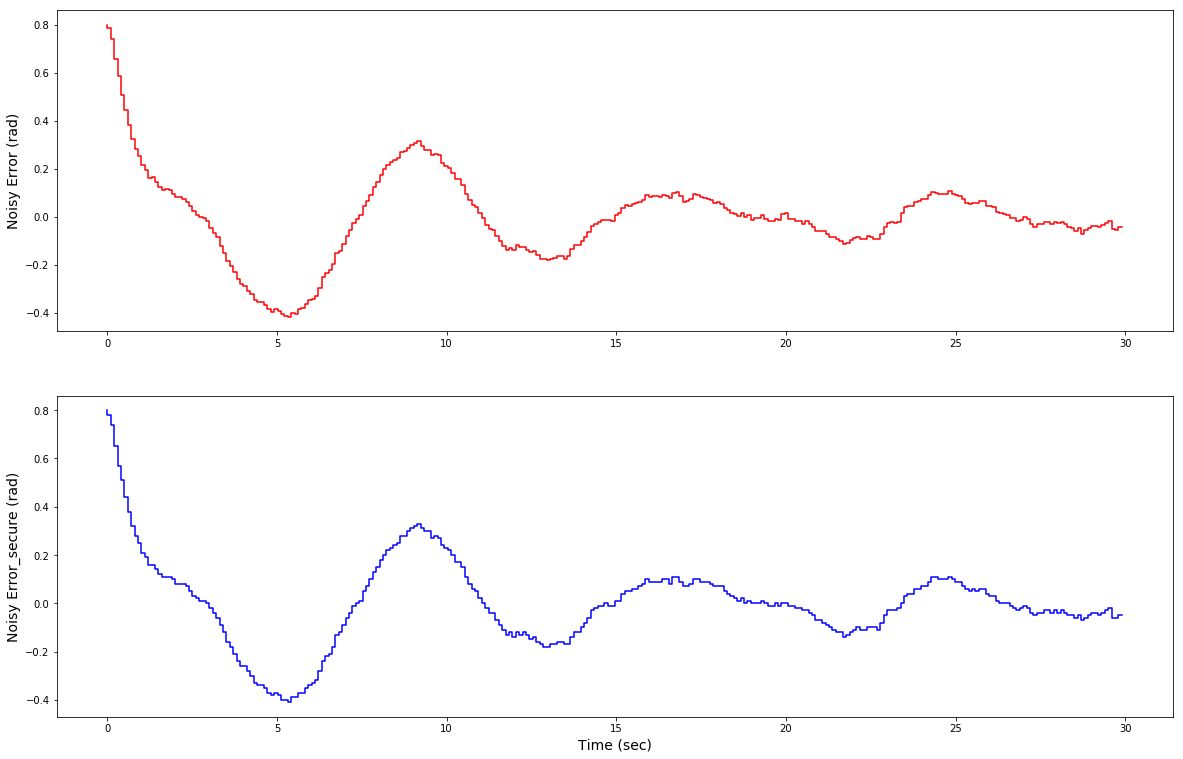

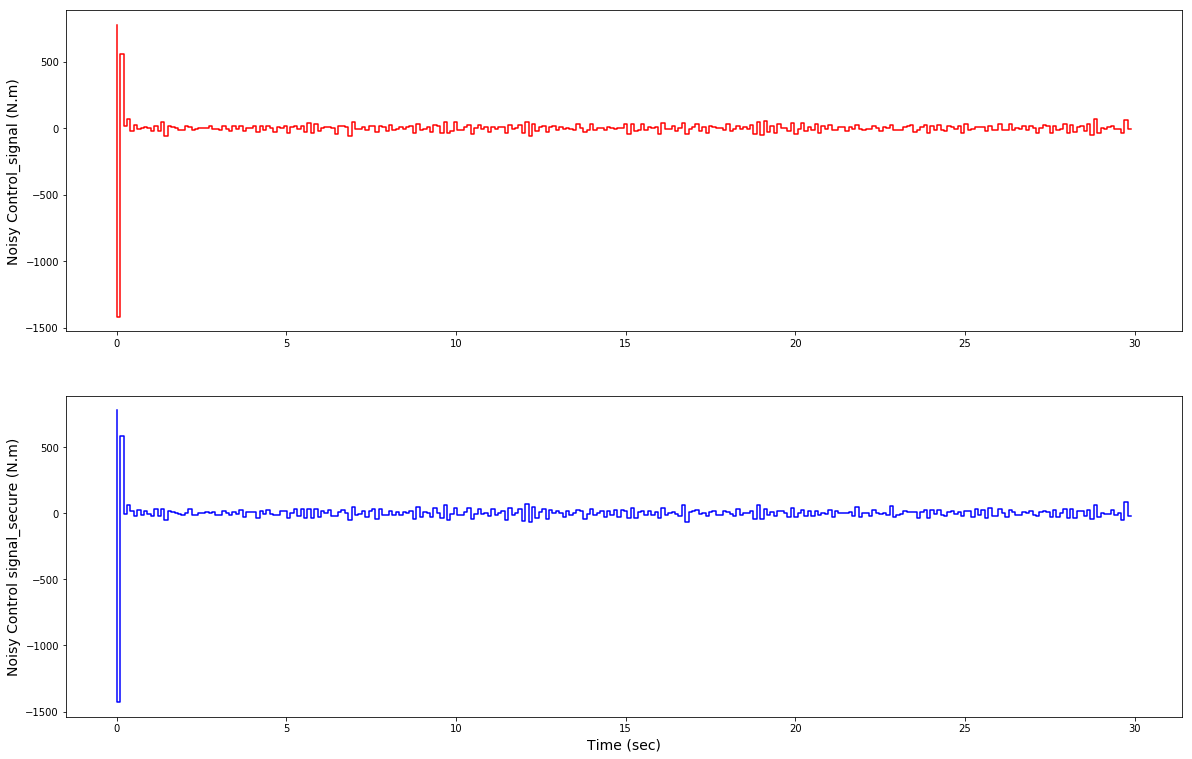

In [12]:
                     ## controlled
                     ########SATELLITE#######
                        ##T=0.1
import time
import numpy as np
import shamirproc
import shamirscheme as sss
from matplotlib import pyplot as plt
from scipy.interpolate import interp1d
from tabulate import tabulate
from decimal import Decimal



Tf=30
#controller parameters
kp = 0.25#800#1.9e+03 # Proportional gain
kd = 0.5#200#178   # Derivative gain
# crypto parameters
F=GF(next_prime(2^32)) #finite field
server=3 # number of computing servers
t=1 #shamir threshold 
scale=2 # A/D and D/A Accuracy

#initial values
sigma=0.01
theta2=0.2
theta2dot,theta1,theta1dot=0,0,0
Theta2=[0.2]
Theta2dot=[0]
Theta1=[0]
Theta1dot=[0]
u=0
dt=0.1
samp=Tf/dt
samp=int(samp)
samples=np.linspace(0,Tf, num=samp)
noise=np.random.normal(0,sigma,samp)


#UNCONTROLLED SYSTEM
for i in range(1,samp):
    
    theta2=0.995459788246996*theta2+0.099668946382836*theta2dot+0.004540211753004*theta1+0.000331053617164*theta1dot+0.000009778468527*u
    theta2dot=-0.090668615329219*theta2+0.991872897970236*theta2dot+0.090668615329219*theta1+0.008127102029764*theta1dot+0.000331053617164*u
    theta1=0.000454021175300*theta2+0.000033105361716*theta2dot+0.999545978824700*theta1+0.099966894638284*theta1dot+0.004999022153147*u
    theta1dot=0.009066861532922*theta2+0.000812710202976*theta2dot-0.009066861532922*theta1+0.999187289797024*theta1dot+0.099966894638284*u
    Theta2.append(theta2)
    Theta2dot.append(theta2dot)
    Theta1.append(theta1)
    Theta1dot.append(theta1dot)
    
#Theta2.pop()
#Theta2dot.pop()
#Theta1.pop()
#Theta1dot.pop()


## #######################Insecure control system#####################
r=1
theta2c=0.2
theta2cdot,theta1c,theta1cdot=0,0,0
Theta2c=[0.2]
Theta2cdot=[0]
Theta1c=[0]
U_c=[]
Theta1cdot=[0]
e,u_pd,u_n=0,0,0
U_pd=[0]
U_n=[0]
error=[0]

tic=time.time()
#CONTROLLED SYSTEM
for i in range(1,samp):
    e=r-theta2c
    u_pd=kp*e+kd*(error[i-2]-4*error[i-1]+3*e)/(2*dt)
    if len(U_n)>1:
        u_n=0.4785*U_n[i-1]-0.006738*U_n[i-2]+125.5*u_pd-250*U_pd[i-1]+125.5*U_pd[i-2]
    else:
        u_n=0.4785*U_n[i-1]+125.5*u_pd-250*U_pd[i-1]
    u_c=u_n
    theta2c=0.995459788246996*theta2c+0.099668946382836*theta2cdot+0.004540211753004*theta1c+0.000331053617164*theta1cdot+0.000009778468527*u_c
    theta2cdot=-0.090668615329219*theta2c+0.991872897970236*theta2cdot+0.090668615329219*theta1c+0.008127102029764*theta1cdot+0.000331053617164*u_c
    theta1c=0.000454021175300*theta2c+0.000033105361716*theta2cdot+0.999545978824700*theta1c+0.099966894638284*theta1cdot+0.004999022153147*u_c
    theta1cdot=0.009066861532922*theta2c+0.000812710202976*theta2cdot-0.009066861532922*theta1c+0.999187289797024*theta1cdot+0.099966894638284*u_c
    U_n.append(u_n)
    U_pd.append(u_pd)
    U_c.append(u_c)
    error.append(e)
    Theta2c.append(theta2c)
    Theta2cdot.append(theta2cdot)
    Theta1c.append(theta1c)
    Theta1cdot.append(theta1cdot)
toc=time.time()

###################### Insecure Noisy control system #######################
theta2cn=0.2
theta2cndot,theta1cn,theta1cndot=0,0,0
Theta2cn=[0.2]
Theta2cndot=[0]
Theta1cn=[0]
U_cn=[]
Theta1cndot=[0]
en,un_pd,un_n=0,0,0
Un_pd=[0]
Un_n=[0]
errorn=[0]

#CONTROLLED SYSTEM
for i in range(1,samp):
    en=r-theta2cn
    un_pd=kp*en+kd*(errorn[i-2]-4*errorn[i-1]+3*en)/(2*dt)
    if len(U_n)>1:
        un_n=0.4785*Un_n[i-1]-0.006738*Un_n[i-2]+125.5*un_pd-250*Un_pd[i-1]+125.5*Un_pd[i-2]
    else:
        un_n=0.4785*Un_n[i-1]+125.5*un_pd-250*Un_pd[i-1]
    un_c=un_n
    theta2cn=0.995459788246996*theta2cn+0.099668946382836*theta2cndot+0.004540211753004*theta1cn+0.000331053617164*theta1cndot+0.000009778468527*un_c+noise[i]
    theta2cndot=-0.090668615329219*theta2cn+0.991872897970236*theta2cndot+0.090668615329219*theta1cn+0.008127102029764*theta1cndot+0.000331053617164*un_c
    theta1cn=0.000454021175300*theta2cn+0.000033105361716*theta2cndot+0.999545978824700*theta1cn+0.099966894638284*theta1cndot+0.004999022153147*un_c
    theta1cndot=0.009066861532922*theta2cn+0.000812710202976*theta2cndot-0.009066861532922*theta1cn+0.999187289797024*theta1cndot+0.099966894638284*un_c
    Un_n.append(un_n)
    Un_pd.append(un_pd)
    U_cn.append(un_c)
    errorn.append(en)
    Theta2cn.append(theta2cn)
    Theta2cndot.append(theta2cndot)
    Theta1cn.append(theta1cn)
    Theta1cndot.append(theta1cndot)


################################################Secure controlled system######################

rs=1
theta2cs=0.2
theta2csdot,theta1cs,theta1csdot=0,0,0
Theta2cs=[0.2]
Theta2csdot=[0]
Theta1cs=[0]
Theta1csdot=[0]
es,us_pd,us_n=0,0,0
us_pd=sss.share(F,us_pd,t,server,scale)
us_n=sss.share(F,us_n,t,server,scale)
Us_pd=[us_pd]
Us_n=[us_n]
Us_c=[]
errors=[sss.share(F,es,t,server,scale)]
errorsh=[0]
kps=sss.share(F,kp,t,server,scale)
kds=sss.share(F,kd,t,server,scale)
rec=sss.basispoly(F,server)
invdts=sss.share(F,1/(2*dt),t,server,scale)
b0=sss.share(F,125.5,t,server,scale)
b1=sss.share(F,-250,t,server,scale)
b2=sss.share(F,125.5,t,server,scale)
a1=sss.share(F,0.4785,t,server,scale)
a2=sss.share(F,-0.0006738,t,server,scale)

tics=time.time()
for i in range(1,samp):
    es=rs-theta2cs
    es=sss.share(F,es,t,server,scale)
    fpcs=shamirproc.mult(F,kps,es,t,server,scale)
    fdcs=shamirproc.mult(F,shamirproc.mult(F,kds,shamirproc.add(F,3*es,
    shamirproc.add(F,-4*errors[i-1],errors[i-2],t,server,scale),t,server,scale)
    ,t,server,scale),invdts,t,server,scale)
    us_pd=shamirproc.add(F,fpcs,fdcs,t,server,scale)
    if len(Us_n)>1:
        us_n= shamirproc.add(F,shamirproc.mult(F,a1,Us_n[i-1],t,server,scale)
            ,shamirproc.add(F,shamirproc.mult(F,a2,Us_n[i-2],t,server,scale)
            ,shamirproc.add(F,shamirproc.mult(F,b0,us_pd,t,server,scale),
            shamirproc.add(F,shamirproc.mult(F,b1,Us_pd[i-1],t,server,scale),
             shamirproc.mult(F,b2,Us_pd[i-2],t,server,scale)
            ,t,server,scale),t,server,scale),t,server,scale),t,server,scale)                                           
    else:
        us_n= shamirproc.add(F,shamirproc.mult(F,a1,Us_n[i-1],t,server,scale)
            ,shamirproc.add(F,shamirproc.mult(F,b0,us_pd,t,server,scale)
           ,shamirproc.mult(F,b1,Us_pd[i-1],t,server,scale)
            ,t,server,scale) ,t,server,scale)                                    
    us_c=sss.rec(F,us_n,rec,scale)
    theta2cs=0.995459788246996*theta2cs+0.099668946382836*theta2csdot+0.004540211753004*theta1cs+0.000331053617164*theta1csdot+0.000009778468527*us_c
    theta2csdot=-0.090668615329219*theta2cs+0.991872897970236*theta2csdot+0.090668615329219*theta1cs+0.008127102029764*theta1csdot+0.000331053617164*us_c
    theta1cs=0.000454021175300*theta2cs+0.000033105361716*theta2csdot+0.999545978824700*theta1cs+0.099966894638284*theta1csdot+0.004999022153147*us_c
    theta1csdot=0.009066861532922*theta2cs+0.000812710202976*theta2csdot-0.009066861532922*theta1cs+0.999187289797024*theta1csdot+0.099966894638284*us_c
    Us_n.append(us_n)
    Us_pd.append(us_pd)
    errors.append(es)
    errorsh.append(sss.rec(F,es,rec,scale))
    Us_c.append(us_c)                                     
    Theta2cs.append(theta2cs)
    Theta2csdot.append(theta2csdot)
    Theta1cs.append(theta1cs)
    Theta1csdot.append(theta1csdot)
tocs=time.time()


############################################## Secure Noisy controlled system######################################

rs=1
theta2csn=0.2
theta2csndot,theta1csn,theta1csndot=0,0,0
Theta2csn=[0.2]
Theta2csndot=[0]
Theta1csn=[0]
Theta1csndot=[0]
esn,usn_pd,usn_n=0,0,0
usn_pd=sss.share(F,usn_pd,t,server,scale)
usn_n=sss.share(F,usn_n,t,server,scale)
Usn_pd=[usn_pd]
Usn_n=[usn_n]
Usn_c=[]
errorsn=[sss.share(F,esn,t,server,scale)]
errorshn=[0]
kpsn=sss.share(F,kp,t,server,scale)
kdsn=sss.share(F,kd,t,server,scale)
rec=sss.basispoly(F,server)
invdtsn=sss.share(F,1/(2*dt),t,server,scale)
b0n=sss.share(F,125.5,t,server,scale)
b1n=sss.share(F,-250,t,server,scale)
b2n=sss.share(F,125.5,t,server,scale)
a1n=sss.share(F,0.4785,t,server,scale)
a2n=sss.share(F,-0.0006738,t,server,scale)

for i in range(1,samp):
    esn=rs-theta2csn
    esn=sss.share(F,esn,t,server,scale)
    fpcsn=shamirproc.mult(F,kpsn,esn,t,server,scale)
    fdcsn=shamirproc.mult(F,shamirproc.mult(F,kdsn,shamirproc.add(F,3*esn,
    shamirproc.add(F,-4*errorsn[i-1],errorsn[i-2],t,server,scale),t,server,scale)
    ,t,server,scale),invdtsn,t,server,scale)
    usn_pd=shamirproc.add(F,fpcsn,fdcsn,t,server,scale)
    if len(Us_n)>1:
        usn_n= shamirproc.add(F,shamirproc.mult(F,a1n,Usn_n[i-1],t,server,scale)
            ,shamirproc.add(F,shamirproc.mult(F,a2n,Usn_n[i-2],t,server,scale)
            ,shamirproc.add(F,shamirproc.mult(F,b0n,usn_pd,t,server,scale),
            shamirproc.add(F,shamirproc.mult(F,b1n,Usn_pd[i-1],t,server,scale),
             shamirproc.mult(F,b2n,Usn_pd[i-2],t,server,scale)
            ,t,server,scale),t,server,scale),t,server,scale),t,server,scale)                                           
    else:
        usn_n= shamirproc.add(F,shamirproc.mult(F,a1n,Usn_n[i-1],t,server,scale)
            ,shamirproc.add(F,shamirproc.mult(F,b0n,usn_pd,t,server,scale)
           ,shamirproc.mult(F,b1n,Usn_pd[i-1],t,server,scale)
            ,t,server,scale) ,t,server,scale)                                    
    usn_c=sss.rec(F,usn_n,rec,scale)
    theta2csn=0.995459788246996*theta2csn+0.099668946382836*theta2csndot+0.004540211753004*theta1csn+0.000331053617164*theta1csndot+0.000009778468527*usn_c+noise[i]
    theta2csndot=-0.090668615329219*theta2csn+0.991872897970236*theta2csndot+0.090668615329219*theta1csn+0.008127102029764*theta1csndot+0.000331053617164*usn_c
    theta1csn=0.000454021175300*theta2csn+0.000033105361716*theta2csndot+0.999545978824700*theta1csn+0.099966894638284*theta1csndot+0.004999022153147*usn_c
    theta1csndot=0.009066861532922*theta2csn+0.000812710202976*theta2csndot-0.009066861532922*theta1csn+0.999187289797024*theta1csndot+0.099966894638284*usn_c
    Usn_n.append(usn_n)
    Usn_pd.append(usn_pd)
    errorsn.append(esn)
    errorshn.append(sss.rec(F,esn,rec,scale))
    Usn_c.append(usn_c)                                     
    Theta2csn.append(theta2csn)
    Theta2csndot.append(theta2csndot)
    Theta1csn.append(theta1csn)
    Theta1csndot.append(theta1csndot)



print('running time of insecure controller: {0}'.format(toc-tic))
print('running time of secure controller: {0}'.format(tocs-tics))
print('running time of secure /running time of insecure : {0}'.format((tocs-tics)/(toc-tic)))


#Theta2c.pop()
#Theta2cs.pop()

##INSECURE CONTROLLED SYSTEM STEP RESPONSE CHARACTERISTIC##
print('\n\033[1m'+'INSECURE CONTROLLED SYSTEM STEP RESPONSE CHARACTERISTICS\n'+'\033[0m')
ucont = interp1d(Theta2c,samples) 
u2cont=interp1d(samples,Theta2c) 
#stepresponse of sys
contau = ucont(0.632*r)
contrising = 2.2*contau #ucont(0.85*r)-ucont(0.05*r)
contsettling = ucont(0.98*r)
tau=print('Insecure controlled system constant time :{0}'.format(contau))
risingtime = print('Insecure controlled system risingtime :{0}'.format(contrising)) 
settlingtime = print('Insecure controlled system settlingtime :{0}'.format(contsettling))
if max(Theta2c)>r:
    peakamp=round(max(Theta2c),2)
    overshoot=round(((max(Theta2c)-r)/r)*100,1)
    peaktime=round(ucont(max(Theta2c)),2)
    print('Insecure controlled system "peak amplitude :{0}" "overshoot :{1}" "At time :{2}"'
          .format(peakamp,overshoot,peaktime))

##SECURE STEP CONTROLLED SYSTEM RESPONSE CHARACTERISTIC##
print('\n\033[1m'+'SECURE CONTROLLED SYSTEM STEP RESPONSE CHARACTERISTICS\n'+'\033[0m')
uscont = interp1d(Theta2cs,samples)
u2scont = interp1d(samples,Theta2cs)
#stepresponse of sys
scontau = uscont(0.632*rs)
scontrising =  2.2*scontau#uscont(0.85*rs)-uscont(0.05*rs)
scontsettling = uscont(0.98*rs)
tau=print('Secure controlled system constant time :{0}'.format(scontau))
risingtime = print('Secure controlled system risingtime :{0}'.format(scontrising)) 
settlingtime = print('Secure controlled system settlingtime :{0}'.format(scontsettling))
if max(Theta2cs)>rs:
    peakamps=round(max(Theta2cs)/r,2)
    overshoots=round(((max(Theta2cs)-r)/r)*100,1)
    peaktimes=round(uscont(max(Theta2cs)),2)
    print('Secure controlled system "peak amplitude :{0}" "overshoot :{1}" "At time :{2}"'
          .format(peakamps,overshoots,peaktimes))



    
    
#signal energy and power controlled-insecure
    
theta1cE=0
for i in abs(np.array(Theta1c)):
    theta1cE+=i**2
theta1cP='%.3E' % Decimal(str(theta1cE/samp))
    
theta2cE=0
for i in abs(np.array(Theta2c)):
    theta2cE+=i**2
theta2cP='%.3E' % Decimal(str(theta2cE/samp))
    
dtheta1cE=0
for i in abs(np.array(Theta1cdot)):
    dtheta1cE+=i**2
dtheta1cP='%.3E' % Decimal(str(dtheta1cE/samp))
    
dtheta2cE=0
for i in abs(np.array(Theta2cdot)):
    dtheta2cE+=i**2
dtheta2cP='%.3E' % Decimal(str(dtheta2cE/samp))    
    
ecE=0
for i in abs(np.array(error)):
    ecE+=i**2
ecP='%.3E' % Decimal(str(ecE/samp))
    
fcE=0
for i in abs(np.array(U_n)):
    fcE+=i**2
fcP='%.3E' % Decimal(str(fcE/samp))
    
    
#signal energy and power controlled-secure
    
theta1csE=0
for i in abs(np.array(Theta1cs)):
    theta1csE+=i**2
theta1csP='%.3E' % Decimal(str(theta1csE/samp))
    
theta2csE=0
for i in abs(np.array(Theta2cs)):
    theta2csE+=i**2
theta2csP='%.3E' % Decimal(str(theta2csE/samp))
    
dtheta1csE=0
for i in abs(np.array(Theta1csdot)):
    dtheta1csE+=i**2
dtheta1csP='%.3E' % Decimal(str(dtheta1csE/samp))
    
dtheta2csE=0
for i in abs(np.array(Theta2csdot)):
    dtheta2csE+=i**2
dtheta2csP='%.3E' % Decimal(str(dtheta2csE/samp))    
       
ecsE=0
for i in abs(np.array(errorsh)):
    ecsE+=i**2
ecsP='%.3E' % Decimal(str(ecsE/samp))
    
fcsE=0
for i in abs(np.array(Us_c)):
    fcsE+=i**2
fcsP='%.3E' % Decimal(str(fcsE/samp))
 
    
##differences
theta1diffrence = abs(np.array(Theta1c)-np.array(Theta1cs))
dtheta1diffrence = abs(np.array(Theta1cdot)-np.array(Theta1csdot))
theta2diffrence = abs(np.array(Theta2c)-np.array(Theta2cs))
dtheta2diffrence = abs(np.array(Theta2cdot)-np.array(Theta2csdot))
errordiffrence = abs(np.array(error)-np.array(errorsh))
forcediffrence = abs(np.array(U_c)-np.array(Us_c))
    
    #table of defferences
stheta1=0
for i in theta1diffrence:
    stheta1+=i**2
IAEtheta1= '%.3E' % Decimal(str(sum(theta1diffrence)/samp))
ISEtheta1= '%.3E' % Decimal(str(stheta1/samp))

stheta2=0
for i in theta2diffrence:
    stheta2+=i**2
IAEtheta2= '%.3E' % Decimal(str(sum(theta2diffrence)/samp))
ISEtheta2= '%.3E' % Decimal(str(stheta2/samp))
    
sdtheta1=0
for i in dtheta1diffrence:
    sdtheta1+=i**2
IAEdtheta1= '%.3E' % Decimal(str(sum(dtheta1diffrence)/samp))
ISEdtheta1= '%.3E' % Decimal(str(sdtheta1/samp))

sdtheta2=0
for i in dtheta2diffrence:
    sdtheta2+=i**2
IAEdtheta2= '%.3E' % Decimal(str(sum(dtheta2diffrence)/samp))
ISEdtheta2= '%.3E' % Decimal(str(sdtheta2/samp))
    
se=0
for i in errordiffrence:
    se+=i**2
IAEse= '%.3E' % Decimal(str(sum(errordiffrence)/samp))
ISEse= '%.3E' % Decimal(str(se/samp))
    
sf=0
for i in forcediffrence:
    sf+=i**2
IAEsf= '%.3E' % Decimal(str(sum(forcediffrence)/samp))
ISEsf= '%.3E' % Decimal(str(sf/samp))
    
table = [['Signal','IAE','ISE','Closed Loop/insecure','Closed Loop/Secure']
         ,["theta1",IAEtheta1,ISEtheta1,theta1cP,theta1csP]
        ,["theta2",IAEtheta2,ISEtheta2,theta2cP,theta2csP]
         ,["dtheta1/dt",IAEdtheta1,ISEdtheta1,dtheta1cP,dtheta1csP]
      ,["dtheta2/dt",IAEdtheta2,ISEdtheta2,dtheta2cP,dtheta2csP]
         ,["error signal",IAEse,ISEse,ecP,ecsP]
         ,["control signal",IAEsf,ISEsf,fcP,fcsP]]

headers = ['Signal',"Integral Absolute Error(IAE)\nsum[abs(insecuretheta-securetheta)]/samples", "Integral Squared Error(ISE)\nsum[abs(sqrt(insecuretheta-securetheta))]/samples",'Closed Loop/insecure','Closed Loop/Secure']

print(tabulate(table, headers, tablefmt="pretty",disable_numparse=True))
fold=open('Results.txt','w')
fold.write(tabulate(table))
fold.close()      
    
        
error.pop(0)
errorsh.pop(0)
Theta1c.pop(0)
Theta1cs.pop(0)
errorn.pop(0)
errorshn.pop(0)
Theta1cn.pop(0)
Theta1csn.pop(0)
samples2=np.delete(samples, -1)    
#errors.pop(0)
stepinfo=1

############Theta 2 #instrument package angle##########
#insecure controlled sys

fig,axs = plt.subplots(2, 1)
fig.set_size_inches(20, 13, forward=True)
#fig.suptitle('Controlled System')
axs[0].step(samples,Theta2c,color = 'red')
axs[0].set_ylabel('Theta2 (rad)',fontsize=14)
if stepinfo==True:
    axs[0].scatter(contrising,u2cont(contrising),color = 'blue')
    axs[0].scatter(contsettling,u2cont(contsettling),color = 'blue')
    axs[0].text(contrising,u2cont(contrising),
             '  sys:Insecure controlled\n  RisingTime : {0}'
                   .format(round(contrising,2)),horizontalalignment='left'
                   ,verticalalignment='bottom',fontsize=11)
    axs[0].text(contsettling,u2cont(contsettling),
             '  sys:Insecure controlled\n  Settlingtime : {0}'
                   .format(round(contsettling,2)),verticalalignment='top',fontsize=11)
    if max(Theta2c)>r:
        axs[0].scatter(peaktime,peakamp,color = 'blue')
        axs[0].text(peaktime,peakamp,
             '  sys:Insecure controlled\n  Peak amplitude : {0}\n  Overshoot : {1}\n  At time : {2}'
                 .format(peakamp,overshoot,peaktime),horizontalalignment='left'
                       ,verticalalignment='top',fontsize=11)
axs[0].set_title('Insecure Controlled System')
axs[0].axhline(y = r, color = 'black', linestyle = '--')
axs[0].label_outer()

#secure controlled sys
axs[1].step(samples,Theta2cs,color = 'blue')
if stepinfo==True:
    axs[1].scatter(scontrising,u2scont(scontrising),color = 'red')
    axs[1].scatter(scontsettling,u2scont(scontsettling),color = 'red')
    axs[1].text(scontrising,u2scont(scontrising),
             '  sys:Secure controlled\n  RisingTime : {0}'
                   .format(round(scontrising,2)),horizontalalignment='left'
                   ,verticalalignment='bottom',fontsize=11)
    axs[1].text(scontsettling,u2scont(scontsettling),
             '  sys:Secure controlled\n  Settlingtime : {0}'
                   .format(round(scontsettling,2)),verticalalignment='top',fontsize=11)
    if max(Theta2c)>r:
        axs[1].scatter(peaktimes,peakamps,color = 'red')
        axs[1].text(peaktimes,peakamps,
             '  sys:Secure controlled\n  Peak amplitude : {0}\n  Overshoot : {1}\n  At time : {2}'
                 .format(peakamps,overshoots,peaktimes),horizontalalignment='left'
                       ,verticalalignment='top',fontsize=11)
axs[1].set_title('Secure Controlled System')
axs[1].axhline(y = r, color = 'black', linestyle = '--')
axs[1].set_ylabel('Theta2_secure (rad)',fontsize=14)
axs[1].set_xlabel('Time (sec)',fontsize=14)

##Theta 1 #body angle
fig1,axs1 = plt.subplots(2, 1)
fig1.set_size_inches(20, 13, forward=True)
axs1[0].step(samples2,Theta1c,color = 'red')
axs1[0].axhline(y = r, color = 'black', linestyle = '--')
axs1[0].set_ylabel('Theta1(rad)',fontsize=14)

axs1[1].step(samples2,Theta1cs,color = 'blue')
axs1[1].axhline(y = r, color = 'black', linestyle = '--')
axs1[1].set_ylabel('Theta1_secure(rad)',fontsize=14)
axs1[1].set_xlabel('Time (sec)',fontsize=14)

##error 
fig2,axs2= plt.subplots(2, 1)
fig2.set_size_inches(20, 13, forward=True)
axs2[0].step(samples2,error,color = 'red')
axs2[0].set_ylabel('Error (rad)',fontsize=14)

axs2[1].step(samples2,errorsh,color = 'blue')
axs2[1].set_ylabel('Error_secure (rad)',fontsize=14)
axs2[1].set_xlabel('Time (sec)',fontsize=14)

##control signal 
fig3,axs3= plt.subplots(2, 1)
fig3.set_size_inches(20, 13, forward=True)
axs3[0].step(samples2,U_c,color = 'red')
axs3[0].set_ylabel('Control_signal (N.m)',fontsize=14)

axs3[1].step(samples2,Us_c,color = 'blue')
axs3[1].set_ylabel('Control signal_secure (N.m)',fontsize=14)
axs3[1].set_xlabel('Time (sec)',fontsize=14)

##################sys+Noise#########################

fig4,axs4 = plt.subplots(2, 1)
fig4.set_size_inches(20, 13, forward=True)
#fig.suptitle('Controlled System')
axs4[0].step(samples,Theta2cn,color = 'red')
axs4[0].set_ylabel('Noisy Theta2 (rad)',fontsize=14)
axs4[0].set_title('Insecure Noisy Controlled System')
axs4[0].axhline(y = r, color = 'black', linestyle = '--')
axs4[0].label_outer()

#secure controlled sys
axs4[1].step(samples,Theta2csn,color = 'blue')
axs4[1].set_title('Secure Noisy Controlled System')
axs4[1].axhline(y = r, color = 'black', linestyle = '--')
axs4[1].set_ylabel('Noisy Theta2_secure (rad)',fontsize=14)
axs4[1].set_xlabel('Time (sec)',fontsize=14)

##Theta 1 #body angle
fig5,axs5 = plt.subplots(2, 1)
fig5.set_size_inches(20, 13, forward=True)
axs5[0].step(samples2,Theta1cn,color = 'red')
axs5[0].axhline(y = r, color = 'black', linestyle = '--')
axs5[0].set_ylabel('Noisy Theta1(rad)',fontsize=14)

axs5[1].step(samples2,Theta1csn,color = 'blue')
axs5[1].axhline(y = r, color = 'black', linestyle = '--')
axs5[1].set_ylabel('Noisy Theta1_secure(rad)',fontsize=14)
axs5[1].set_xlabel('Time (sec)',fontsize=14)

##error 
fig6,axs6= plt.subplots(2, 1)
fig6.set_size_inches(20, 13, forward=True)
axs6[0].step(samples2,errorn,color = 'red')
axs6[0].set_ylabel('Noisy Error (rad)',fontsize=14)

axs6[1].step(samples2,errorshn,color = 'blue')
axs6[1].set_ylabel('Noisy Error_secure (rad)',fontsize=14)
axs6[1].set_xlabel('Time (sec)',fontsize=14)

##control signal 
fig7,axs7= plt.subplots(2, 1)
fig7.set_size_inches(20, 13, forward=True)
axs7[0].step(samples2,U_cn,color = 'red')
axs7[0].set_ylabel('Noisy Control_signal (N.m)',fontsize=14)

axs7[1].step(samples2,Usn_c,color = 'blue')
axs7[1].set_ylabel('Noisy Control signal_secure (N.m)',fontsize=14)
axs7[1].set_xlabel('Time (sec)',fontsize=14)

In [37]:
sss.rec(F,([11516850909190509269 ,4586957744051466909 ,16103808652621976178]),rec,scale)

6.2

In [59]:
samples
np.delete(samples, -1)

array([ 0.        ,  0.1002004 ,  0.2004008 ,  0.3006012 ,  0.4008016 ,
        0.501002  ,  0.6012024 ,  0.70140281,  0.80160321,  0.90180361,
        1.00200401,  1.10220441,  1.20240481,  1.30260521,  1.40280561,
        1.50300601,  1.60320641,  1.70340681,  1.80360721,  1.90380762,
        2.00400802,  2.10420842,  2.20440882,  2.30460922,  2.40480962,
        2.50501002,  2.60521042,  2.70541082,  2.80561122,  2.90581162,
        3.00601202,  3.10621242,  3.20641283,  3.30661323,  3.40681363,
        3.50701403,  3.60721443,  3.70741483,  3.80761523,  3.90781563,
        4.00801603,  4.10821643,  4.20841683,  4.30861723,  4.40881764,
        4.50901804,  4.60921844,  4.70941884,  4.80961924,  4.90981964,
        5.01002004,  5.11022044,  5.21042084,  5.31062124,  5.41082164,
        5.51102204,  5.61122244,  5.71142285,  5.81162325,  5.91182365,
        6.01202405,  6.11222445,  6.21242485,  6.31262525,  6.41282565,
        6.51302605,  6.61322645,  6.71342685,  6.81362725,  6.91

In [13]:
len(Theta2c)

299

In [ ]:
#insecure controlled sys

fig4,axs4 = plt.subplots(2, 1)
fig.set_size_inches(20, 13, forward=True)
#fig.suptitle('Controlled System')
axs4[0].step(samples,Theta2cn,color = 'red')
axs4[0].set_ylabel('Noisy Theta2 (rad)',fontsize=14)
axs4[0].set_title('Insecure Noisy Controlled System')
axs4[0].axhline(y = r, color = 'black', linestyle = '--')
axs4[0].label_outer()

#secure controlled sys
axs4[1].step(samples,Theta2csn,color = 'blue')
axs4[1].set_title('Secure Noisy Controlled System')
axs4[1].axhline(y = r, color = 'black', linestyle = '--')
axs4[1].set_ylabel('Noisy Theta2_secure (rad)',fontsize=14)
axs4[1].set_xlabel('Time (sec)',fontsize=14)

##Theta 1 #body angle
fig5,axs5 = plt.subplots(2, 1)
fig5.set_size_inches(20, 13, forward=True)
axs5[0].step(samples2,Theta1cn,color = 'red')
axs5[0].axhline(y = r, color = 'black', linestyle = '--')
axs5[0].set_ylabel('Noisy Theta1(rad)',fontsize=14)

axs5[1].step(samples2,Theta1csn,color = 'blue')
axs5[1].axhline(y = r, color = 'black', linestyle = '--')
axs5[1].set_ylabel('Noisy Theta1_secure(rad)',fontsize=14)
axs5[1].set_xlabel('Time (sec)',fontsize=14)

##error 
fig6,axs6= plt.subplots(2, 1)
fig6.set_size_inches(20, 13, forward=True)
axs6[0].step(samples2,errorn,color = 'red')
axs6[0].set_ylabel('Noisy Error (rad)',fontsize=14)

axs6[1].step(samples2,errorshn,color = 'blue')
axs6[1].set_ylabel('Noisy Error_secure (rad)',fontsize=14)
axs6[1].set_xlabel('Time (sec)',fontsize=14)

##control signal 
fig7,axs7= plt.subplots(2, 1)
fig7.set_size_inches(20, 13, forward=True)
axs7[0].step(samples2,Un_c,color = 'red')
axs7[0].set_ylabel('Control_signal (N.m)',fontsize=14)

axs7[1].step(samples2,Usn_c,color = 'blue')
axs7[1].set_ylabel('Control signal_secure (N.m)',fontsize=14)
axs7[1].set_xlabel('Time (sec)',fontsize=14)